## Preamble

In [169]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

from cpymad.madx import Madx

# Comment out the following lines if plotting cells give an error
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
from plot_settings import setPlotSettings
setPlotSettings(font=True)

## Case 1

### Interpolate

In [170]:
madx_interp = Madx(stdout=False)
madx_interp.input(f'''
!==================================================
! RHIC FODO cell
! Authors: Todd Satogata, Steve Peggs 
! Last edited: February 28 2024
!==================================================

BEAM, particle = proton, energy = 275.0;
ASSIGN, echo = madx.log;

TITLE,'RHIC fodo cell';

! Geometry
LQUAD = 1.11;                               ! Total quad length
LDIP  = 9.45;                               ! Arc dipole length
THETA = 0.038924;                           ! Arc dipole bend angle 

! Strengths
KF =  0.09020;                              ! m^(-2)
KD = -0.09320;                              ! m^(-2)

! Magnets
QFH: QUADRUPOLE, L = 0.5*LQUAD, K1= KF;           ! HALF quads
QDH: QUADRUPOLE, L = 0.5*LQUAD, K1= KD;
DRI: DRIFT,      L = 2.116775;
DIPRHIC: SBEND,  L = LDIP, ANGLE = THETA;         ! Main arc dipole
SLICE: SBEND,    L = 0.1*LDIP, ANGLE = 0.1*THETA; ! Slice of a dipole

! Beamlines
fodo_rhic:   LINE=(QFH, DRI, DIPRHIC,  DRI, 2*QDH, DRI, DIPRHIC,  DRI, QFH);
fodo_sliced: LINE=(QFH, DRI, 10*SLICE, DRI, 2*QDH, DRI, 10*SLICE, DRI, QFH);

! Define the columns & formats used in the *.twi output files
SELECT, FLAG=TWISS, COLUMN = name,s,betx,bety,alfx,alfy,dx,mux,muy;
SET, format="-22s", "11.6f";

USE, SEQUENCE = fodo_rhic;
MATCH, SEQUENCE = fodo_rhic;
TWISS, SAVE, FILE = fodo_rhic.twi;
PLOT, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

USE, SEQUENCE = fodo_sliced;
MATCH, SEQUENCE = fodo_sliced;
TWISS, SAVE, FILE = fodo_sliced.twi;
PLOT, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

USE, SEQUENCE = fodo_rhic;
MATCH, SEQUENCE = fodo_rhic;
TWISS, SAVE, FILE = fodo_interpolate.twi;
PLOT, interpolate, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

stop;
''')
twiss_interp = madx_interp.table.twiss

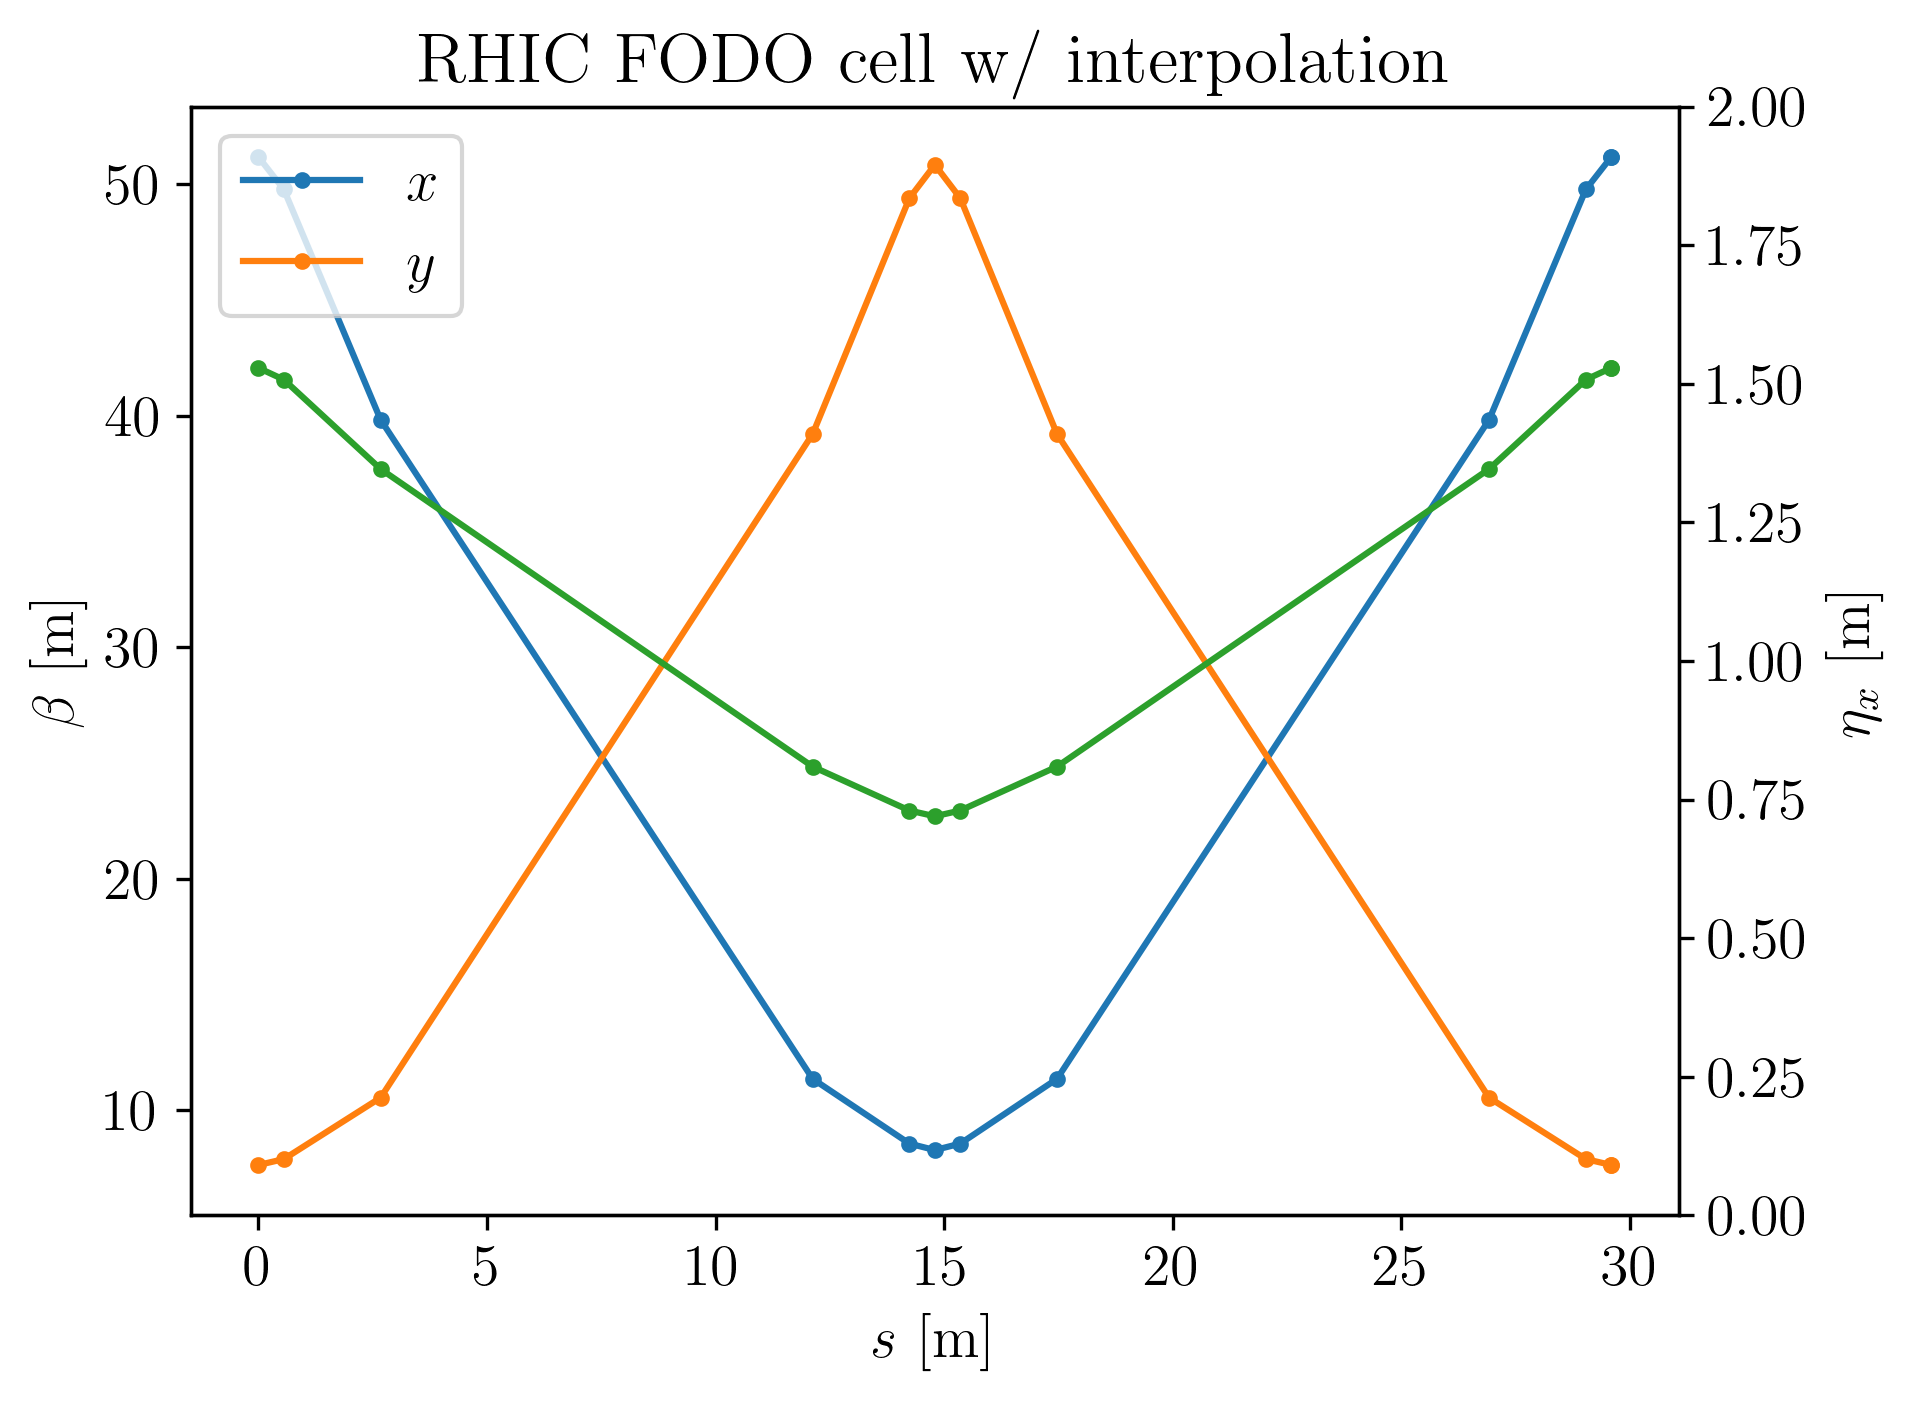

In [171]:
fig, ax1 = plt.subplots()
plt.title('RHIC FODO cell w/ interpolation')
ax1.plot(twiss_interp.s,twiss_interp.betx,'.-',label='$x$')
ax1.plot(twiss_interp.s,twiss_interp.bety,'.-',label='$y$')
ax1.set_ylabel(r'$\beta$ [m]')
ax1.set_xlabel('$s$ [m]')
ax2 = ax1.twinx()
ax2.plot(twiss_interp.s,twiss_interp.dx,'.-',color='tab:green')
ax2.set_ylabel(r'$\eta_x$ [m]')
ax2.set_ylim((0.0,2.0))
ax1.legend(loc='upper left')
plt.show()

### No slice, no interpolate

In [172]:
madx_rhic = Madx(stdout=False)
madx_rhic.input(f'''
BEAM, particle = proton, energy = 275.0;

! Geometry
LQUAD = 1.11;                               ! Total quad length
LDIP  = 9.45;                               ! Arc dipole length
THETA = 0.038924;                           ! Arc dipole bend angle 

! Strengths
KF =  0.09020;                              ! m^(-2)
KD = -0.09320;                              ! m^(-2)

! Magnets
QFH: QUADRUPOLE, L = 0.5*LQUAD, K1= KF;           ! HALF quads
QDH: QUADRUPOLE, L = 0.5*LQUAD, K1= KD;
DRI: DRIFT,      L = 2.116775;
DIPRHIC: SBEND,  L = LDIP, ANGLE = THETA;         ! Main arc dipole
SLICE: SBEND,    L = 0.1*LDIP, ANGLE = 0.1*THETA; ! Slice of a dipole

! Beamlines
fodo_rhic:   LINE=(QFH, DRI, DIPRHIC,  DRI, 2*QDH, DRI, DIPRHIC,  DRI, QFH);
fodo_sliced: LINE=(QFH, DRI, 10*SLICE, DRI, 2*QDH, DRI, 10*SLICE, DRI, QFH);

! Define the columns & formats used in the *.twi output files
SELECT, FLAG=TWISS, COLUMN = name,s,betx,bety,alfx,alfy,dx,mux,muy;
SET, format="-22s", "11.6f";

USE, SEQUENCE = fodo_rhic;
MATCH, SEQUENCE = fodo_rhic;
TWISS, SAVE, FILE = fodo_rhic.twi;
return;
''')
twiss_rhic = madx_rhic.table.twiss

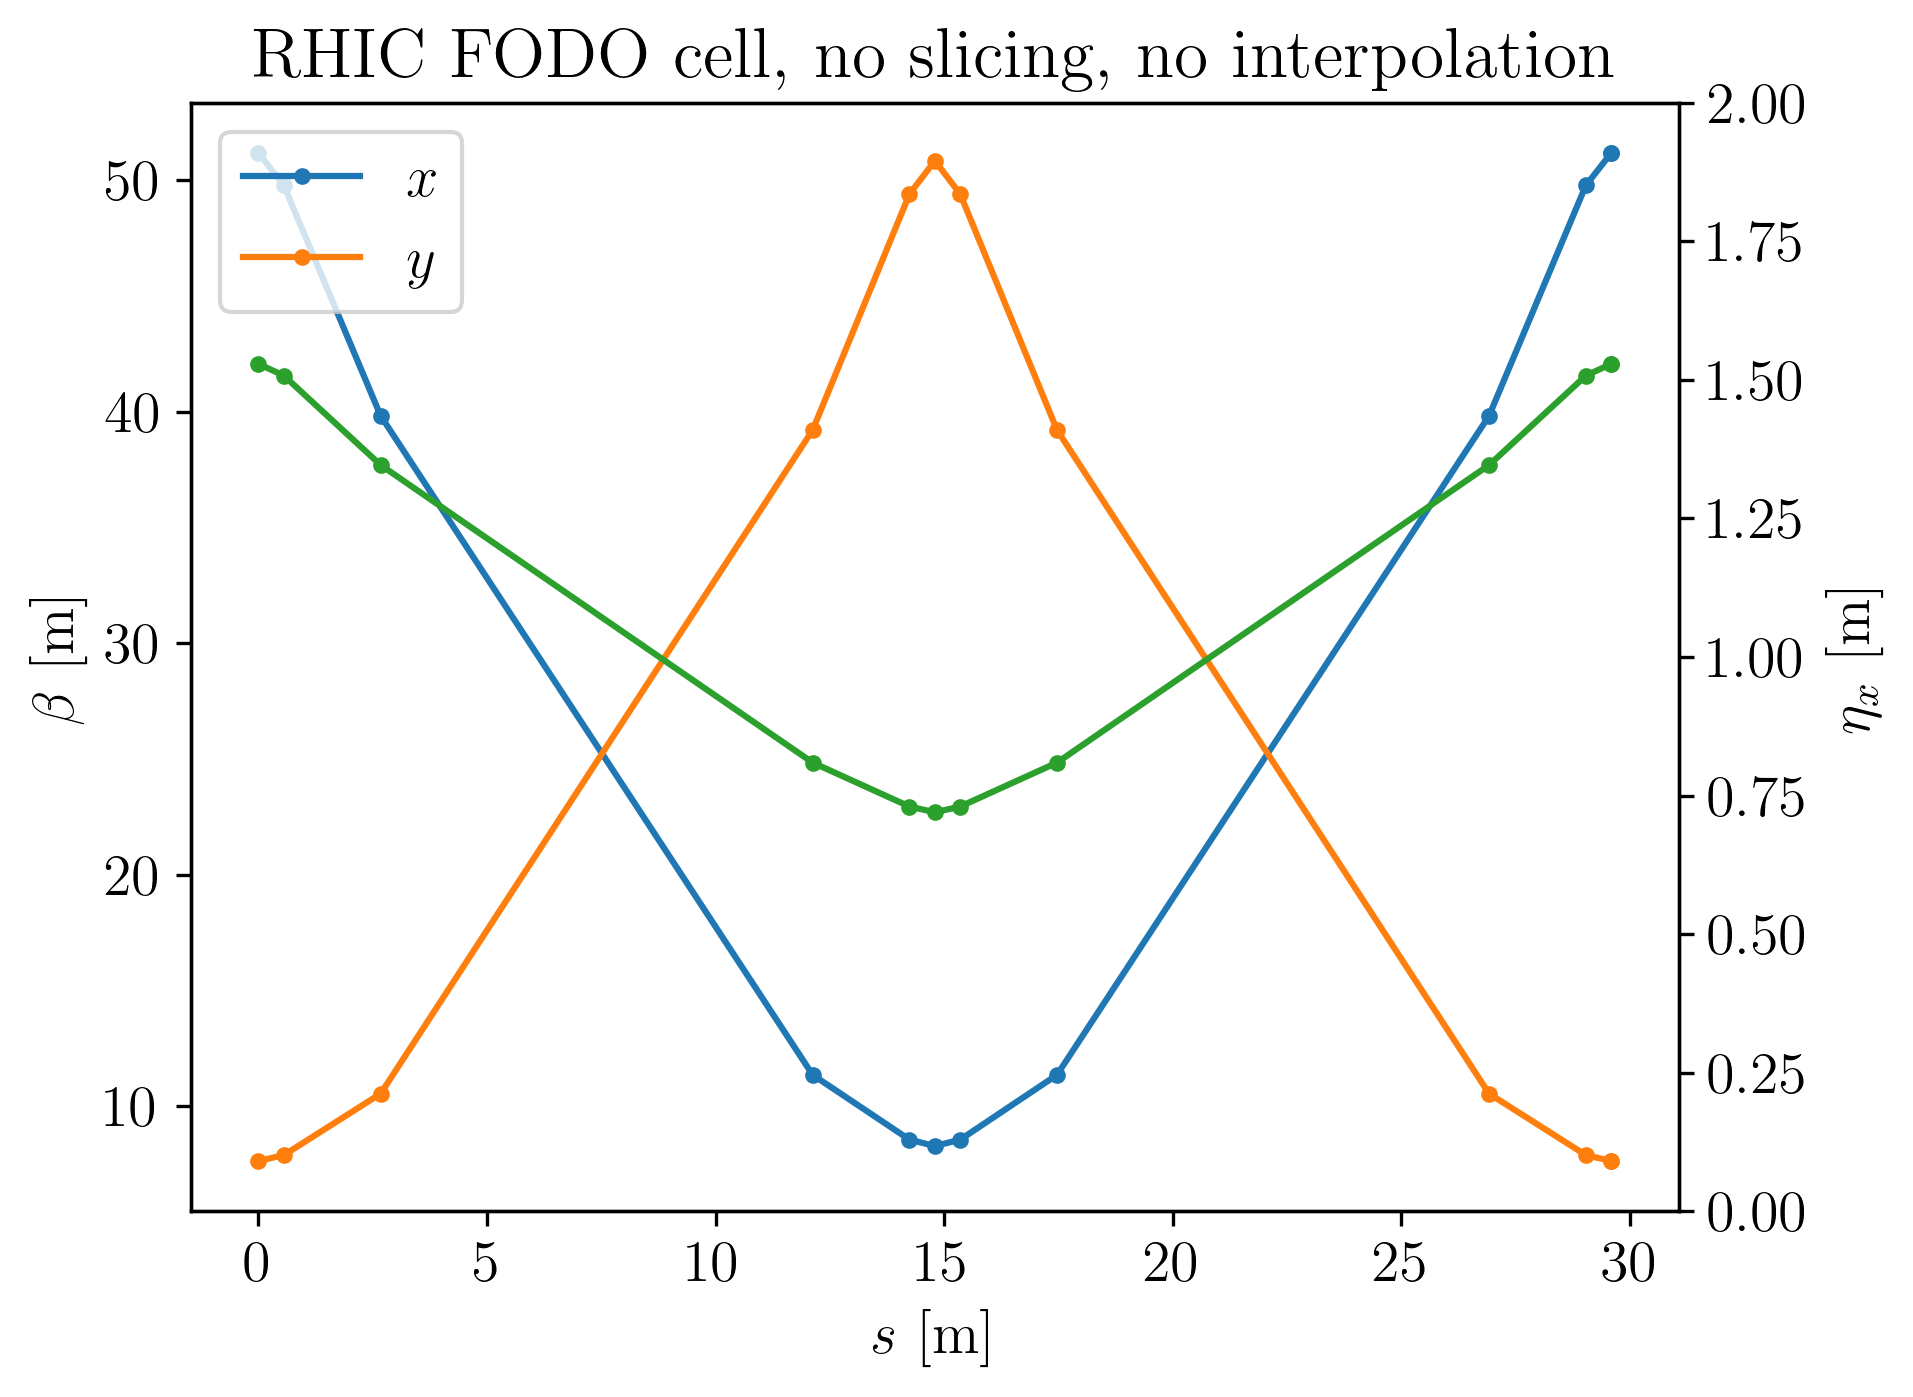

In [173]:
fig, ax1 = plt.subplots()
plt.title('RHIC FODO cell, no slicing, no interpolation')
ax1.plot(twiss_rhic.s,twiss_rhic.betx,'.-',label='$x$')
ax1.plot(twiss_rhic.s,twiss_rhic.bety,'.-',label='$y$')
ax1.set_ylabel(r'$\beta$ [m]')
ax1.set_xlabel('$s$ [m]')
ax2 = ax1.twinx()
ax2.plot(twiss_rhic.s,twiss_rhic.dx,'.-',color='tab:green')
ax2.set_ylabel(r'$\eta_x$ [m]')
ax2.set_ylim((0.0,2.0))
ax1.legend(loc='upper left')
plt.show()

### Slice

In [174]:
madx_sliced = Madx(stdout=False)
madx_sliced.input(f'''
BEAM, particle = proton, energy = 275.0;

! Geometry
LQUAD = 1.11;                               ! Total quad length
LDIP  = 9.45;                               ! Arc dipole length
THETA = 0.038924;                           ! Arc dipole bend angle 

! Strengths
KF =  0.09020;                              ! m^(-2)
KD = -0.09320;                              ! m^(-2)

! Magnets
QFH: QUADRUPOLE, L = 0.5*LQUAD, K1= KF;           ! HALF quads
QDH: QUADRUPOLE, L = 0.5*LQUAD, K1= KD;
DRI: DRIFT,      L = 2.116775;
DIPRHIC: SBEND,  L = LDIP, ANGLE = THETA;         ! Main arc dipole
SLICE: SBEND,    L = 0.1*LDIP, ANGLE = 0.1*THETA; ! Slice of a dipole

! Beamlines
fodo_rhic:   LINE=(QFH, DRI, DIPRHIC,  DRI, 2*QDH, DRI, DIPRHIC,  DRI, QFH);
fodo_sliced: LINE=(QFH, DRI, 10*SLICE, DRI, 2*QDH, DRI, 10*SLICE, DRI, QFH);

! Define the columns & formats used in the *.twi output files
SELECT, FLAG=TWISS, COLUMN = name,s,betx,bety,alfx,alfy,dx,mux,muy;
SET, format="-22s", "11.6f";

USE, SEQUENCE = fodo_sliced;
MATCH, SEQUENCE = fodo_sliced;
TWISS, SAVE, FILE = fodo_sliced.twi;
return;
''')
twiss_sliced = madx_sliced.table.twiss

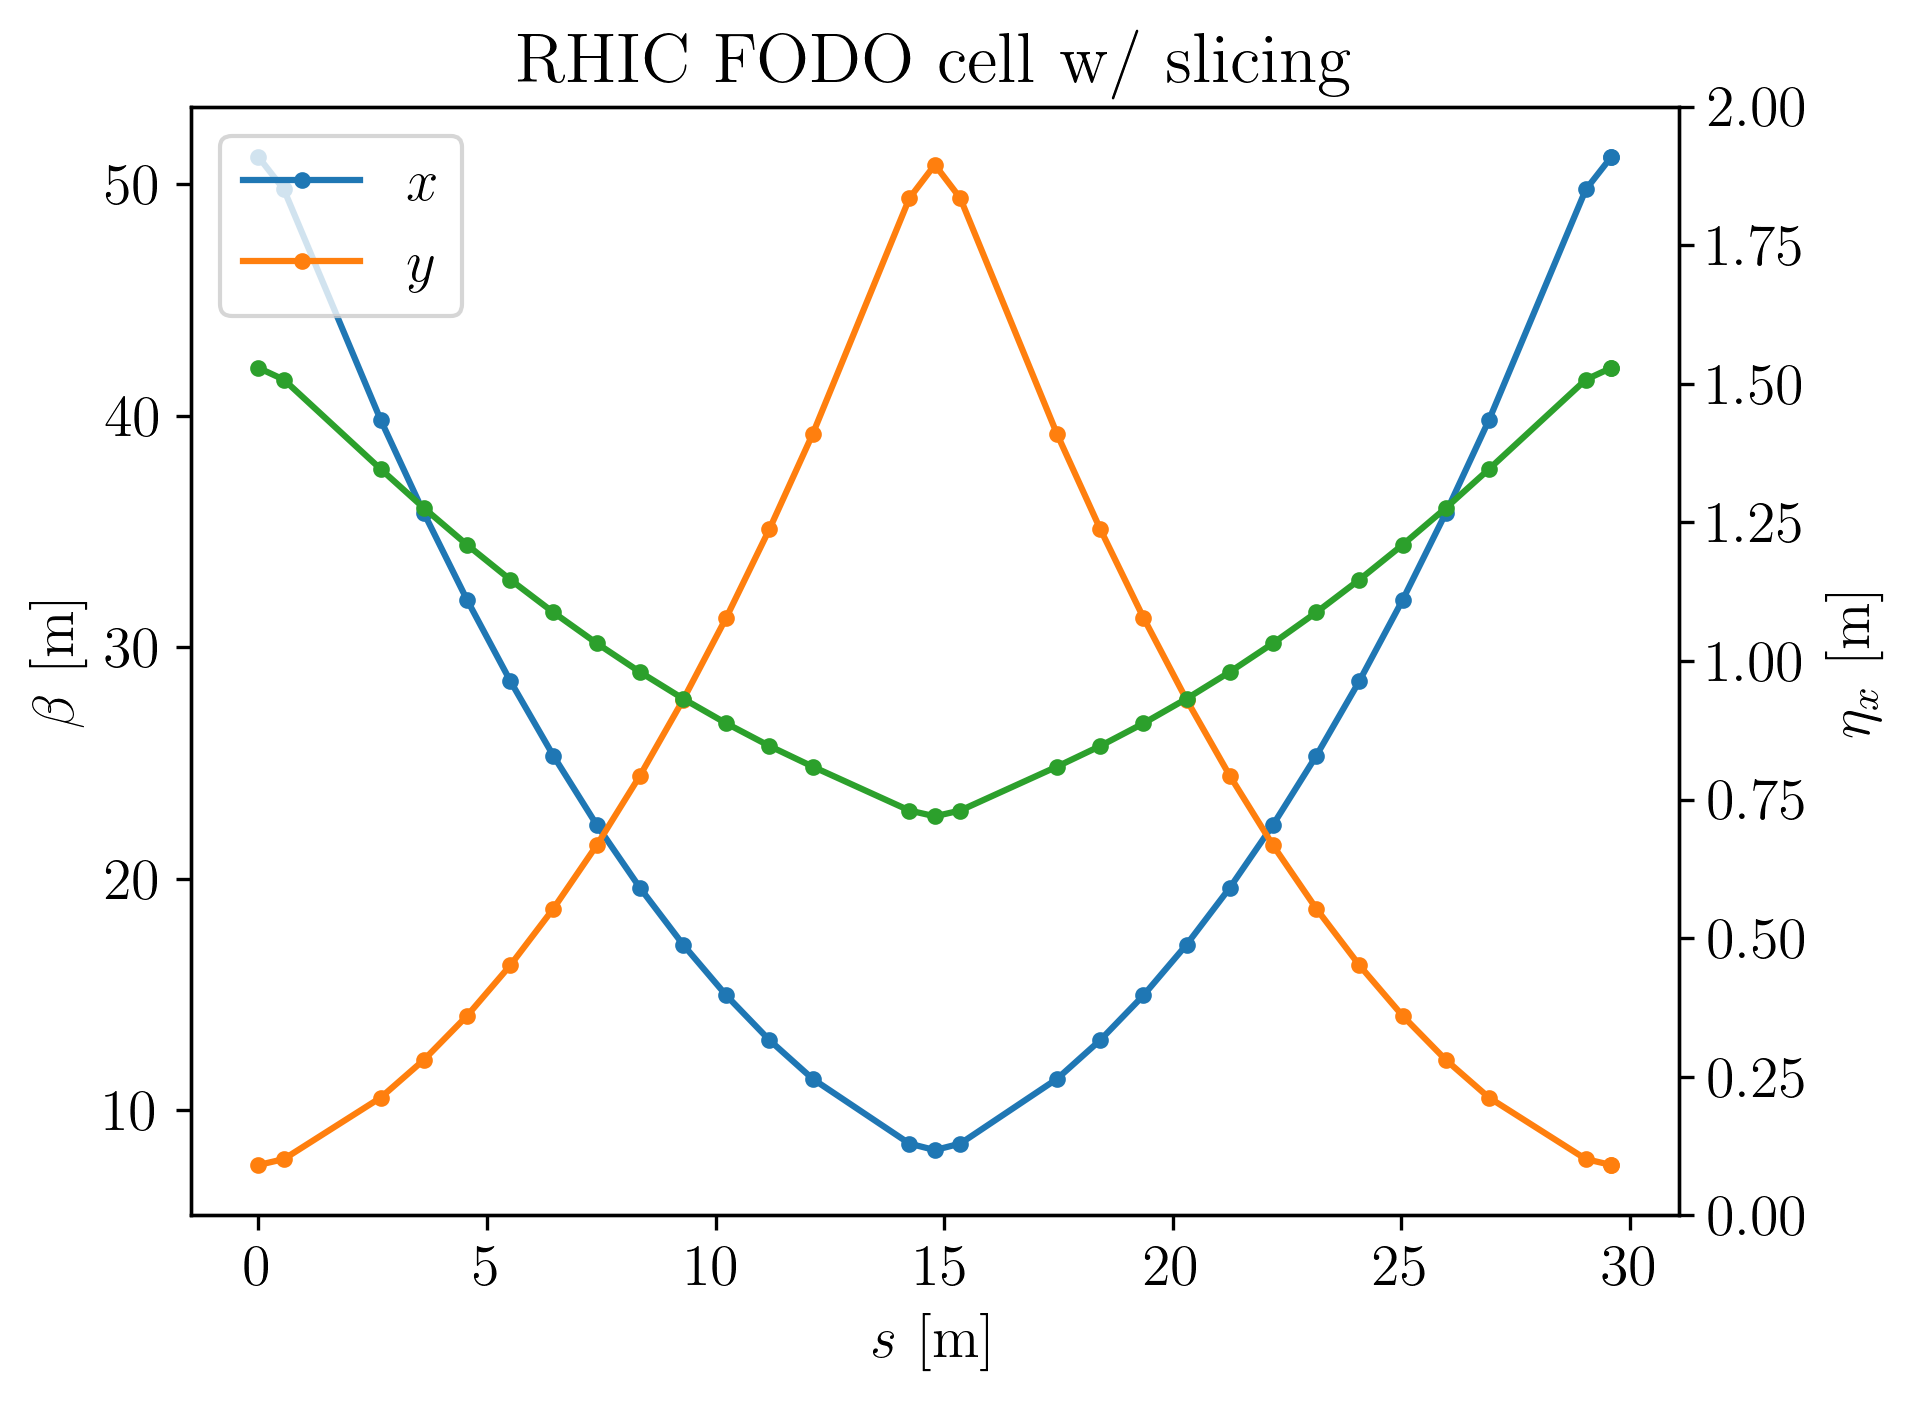

In [175]:
fig, ax1 = plt.subplots()
plt.title('RHIC FODO cell w/ slicing')
ax1.plot(twiss_sliced.s,twiss_sliced.betx,'.-',label='$x$')
ax1.plot(twiss_sliced.s,twiss_sliced.bety,'.-',label='$y$')
ax1.set_ylabel(r'$\beta$ [m]')
ax1.set_xlabel('$s$ [m]')
ax2 = ax1.twinx()
ax2.plot(twiss_sliced.s,twiss_sliced.dx,'.-',color='tab:green')
ax2.set_ylabel(r'$\eta_x$ [m]')
ax2.set_ylim((0.0,2.0))
ax1.legend(loc='upper left')
plt.show()

The interpolation only affects the MADX plotting procedure. $\implies$ The **fodo_rhic.twi and fodo_interpolate.twi** files appear to be identical, as shown in the plots above. 

However, the **interpolated and sliced plots** from MADX look the same because the interpolate function acts to smooth out the regions inside the full length dipole.

## Case 2 -- adjust bend angle

In [176]:
madx_twotheta = Madx(stdout=False)
madx_twotheta.input(f'''
!==================================================
! RHIC FODO cell
! Authors: Todd Satogata, Steve Peggs 
! Last edited: February 28 2024
!==================================================

BEAM, particle = proton, energy = 275.0;
ASSIGN, echo = madx.log;

TITLE,'RHIC fodo cell';

! Geometry
LQUAD = 1.11;                               ! Total quad length
LDIP  = 9.45;                               ! Arc dipole length
THETA = 2*0.038924;                           ! Arc dipole bend angle 

! Strengths
KF =  0.09020;                              ! m^(-2)
KD = -0.09320;                              ! m^(-2)

! Magnets
QFH: QUADRUPOLE, L = 0.5*LQUAD, K1= KF;           ! HALF quads
QDH: QUADRUPOLE, L = 0.5*LQUAD, K1= KD;
DRI: DRIFT,      L = 2.116775;
DIPRHIC: SBEND,  L = LDIP, ANGLE = THETA;         ! Main arc dipole
SLICE: SBEND,    L = 0.1*LDIP, ANGLE = 0.1*THETA; ! Slice of a dipole

! Beamlines
fodo_rhic:   LINE=(QFH, DRI, DIPRHIC,  DRI, 2*QDH, DRI, DIPRHIC,  DRI, QFH);
fodo_sliced: LINE=(QFH, DRI, 10*SLICE, DRI, 2*QDH, DRI, 10*SLICE, DRI, QFH);

! Define the columns & formats used in the *.twi output files
SELECT, FLAG=TWISS, COLUMN = name,s,betx,bety,alfx,alfy,dx,mux,muy;
SET, format="-22s", "11.6f";

USE, SEQUENCE = fodo_rhic;
MATCH, SEQUENCE = fodo_rhic;
TWISS, SAVE, FILE = fodo_rhic.twi;
PLOT, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

USE, SEQUENCE = fodo_sliced;
MATCH, SEQUENCE = fodo_sliced;
TWISS, SAVE, FILE = fodo_sliced.twi;
PLOT, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

USE, SEQUENCE = fodo_rhic;
MATCH, SEQUENCE = fodo_rhic;
TWISS, SAVE, FILE = fodo_interpolate.twi;
PLOT, interpolate, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

stop;
''')
twiss_twotheta = madx_twotheta.table.twiss

In [177]:
madx_halftheta = Madx(stdout=False)
madx_halftheta.input(f'''
!==================================================
! RHIC FODO cell
! Authors: Todd Satogata, Steve Peggs 
! Last edited: February 28 2024
!==================================================

BEAM, particle = proton, energy = 275.0;
ASSIGN, echo = madx.log;

TITLE,'RHIC fodo cell';

! Geometry
LQUAD = 1.11;                               ! Total quad length
LDIP  = 9.45;                               ! Arc dipole length
THETA = 0.038924/2;                           ! Arc dipole bend angle 

! Strengths
KF =  0.09020;                              ! m^(-2)
KD = -0.09320;                              ! m^(-2)

! Magnets
QFH: QUADRUPOLE, L = 0.5*LQUAD, K1= KF;           ! HALF quads
QDH: QUADRUPOLE, L = 0.5*LQUAD, K1= KD;
DRI: DRIFT,      L = 2.116775;
DIPRHIC: SBEND,  L = LDIP, ANGLE = THETA;         ! Main arc dipole
SLICE: SBEND,    L = 0.1*LDIP, ANGLE = 0.1*THETA; ! Slice of a dipole

! Beamlines
fodo_rhic:   LINE=(QFH, DRI, DIPRHIC,  DRI, 2*QDH, DRI, DIPRHIC,  DRI, QFH);
fodo_sliced: LINE=(QFH, DRI, 10*SLICE, DRI, 2*QDH, DRI, 10*SLICE, DRI, QFH);

! Define the columns & formats used in the *.twi output files
SELECT, FLAG=TWISS, COLUMN = name,s,betx,bety,alfx,alfy,dx,mux,muy;
SET, format="-22s", "11.6f";

USE, SEQUENCE = fodo_rhic;
MATCH, SEQUENCE = fodo_rhic;
TWISS, SAVE, FILE = fodo_rhic.twi;
PLOT, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

USE, SEQUENCE = fodo_sliced;
MATCH, SEQUENCE = fodo_sliced;
TWISS, SAVE, FILE = fodo_sliced.twi;
PLOT, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

USE, SEQUENCE = fodo_rhic;
MATCH, SEQUENCE = fodo_rhic;
TWISS, SAVE, FILE = fodo_interpolate.twi;
PLOT, interpolate, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

stop;
''')
twiss_halftheta = madx_halftheta.table.twiss

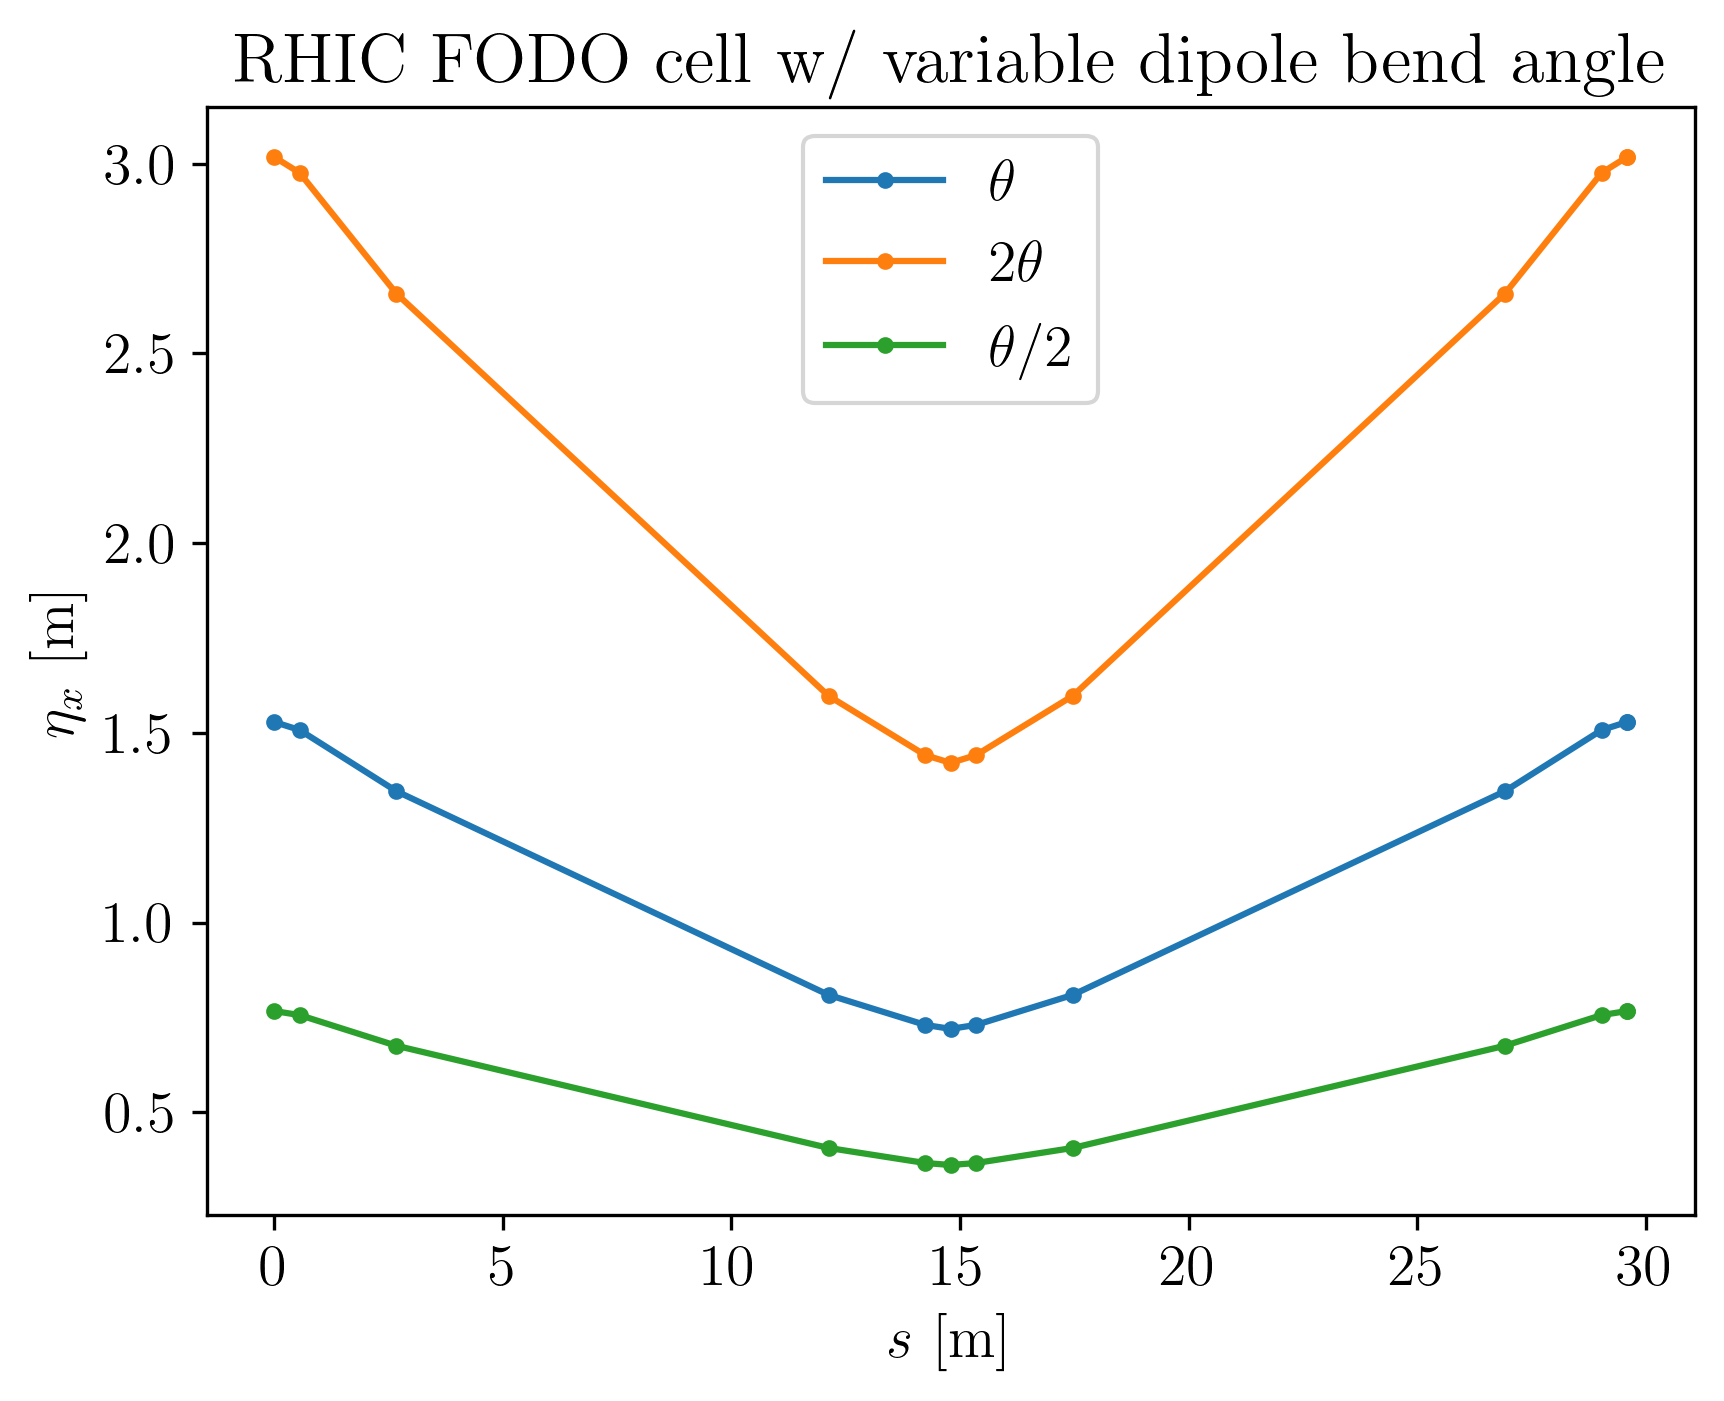

In [178]:
plt.title('RHIC FODO cell w/ variable dipole bend angle')
plt.plot(twiss_rhic.s,twiss_rhic.dx,'.-',label=r'$\theta$')
plt.plot(twiss_twotheta.s,twiss_twotheta.dx,'.-',label=r'$2\theta$')
plt.plot(twiss_halftheta.s,twiss_halftheta.dx,'.-',label=r'$\theta/2$')
plt.xlabel('$s$ [m]')
plt.ylabel(r'$\eta_x$ [m]')
plt.legend()
plt.show()

### Observation

- $\eta_x \propto \theta^2$ $\implies$ Increasing the dipole bend angle $\theta$ makes the parabola thinner (i.e. larger dispersion globally, especially at the extrema). Conversely, decreasing the bend angle makes the parabola wider, with smaller dispersion.

In [179]:
############## fit to see if the data does indeed agree with this function ##############

## Case 3 -- adjust lengths

In [180]:
madx = Madx(stdout=False)
madx.input(f'''
!==================================================
! RHIC FODO cell
! Authors: Todd Satogata, Steve Peggs 
! Last edited: February 28 2024
!==================================================

BEAM, particle = proton, energy = 275.0;
ASSIGN, echo = madx.log;

TITLE,'RHIC fodo cell';

! Geometry
LQUAD = 1.11;                               ! Total quad length
LDIP  = 9.45;                               ! Arc dipole length
THETA = 0.038924;                           ! Arc dipole bend angle 

! Strengths
KF =  0.09020;                              ! m^(-2)
KD = -0.09320;                              ! m^(-2)

! Magnets
QFH: QUADRUPOLE, L = 0.5*LQUAD, K1= KF/2.025;           ! HALF quads
QDH: QUADRUPOLE, L = 0.5*LQUAD, K1= KD/2.025;
DRI: DRIFT,      L = 2.116775*4.4944;
DIPRHIC: SBEND,  L = LDIP, ANGLE = THETA;         ! Main arc dipole
SLICE: SBEND,    L = 0.1*LDIP, ANGLE = 0.1*THETA; ! Slice of a dipole

! Beamlines
fodo_rhic:   LINE=(QFH, DRI, DIPRHIC,  DRI, 2*QDH, DRI, DIPRHIC,  DRI, QFH);
fodo_sliced: LINE=(QFH, DRI, 10*SLICE, DRI, 2*QDH, DRI, 10*SLICE, DRI, QFH);

! Define the columns & formats used in the *.twi output files
SELECT, FLAG=TWISS, COLUMN = name,s,betx,bety,alfx,alfy,dx,mux,muy;
SET, format="-22s", "11.6f";

USE, SEQUENCE = fodo_rhic;
MATCH, SEQUENCE = fodo_rhic;
TWISS, SAVE, FILE = fodo_rhic.twi;
PLOT, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

USE, SEQUENCE = fodo_sliced;
MATCH, SEQUENCE = fodo_sliced;
TWISS, SAVE, FILE = fodo_sliced.twi;
PLOT, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

USE, SEQUENCE = fodo_rhic;
MATCH, SEQUENCE = fodo_rhic;
TWISS, SAVE, FILE = fodo_interpolate.twi;
PLOT, interpolate, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

stop;
''')
twiss = madx.table.twiss

Manually tune parameters to have phase advance be invariant:

DRI $\rightarrow$ DRI*4.4944

K $\rightarrow$ K/2.025

### Phase advance

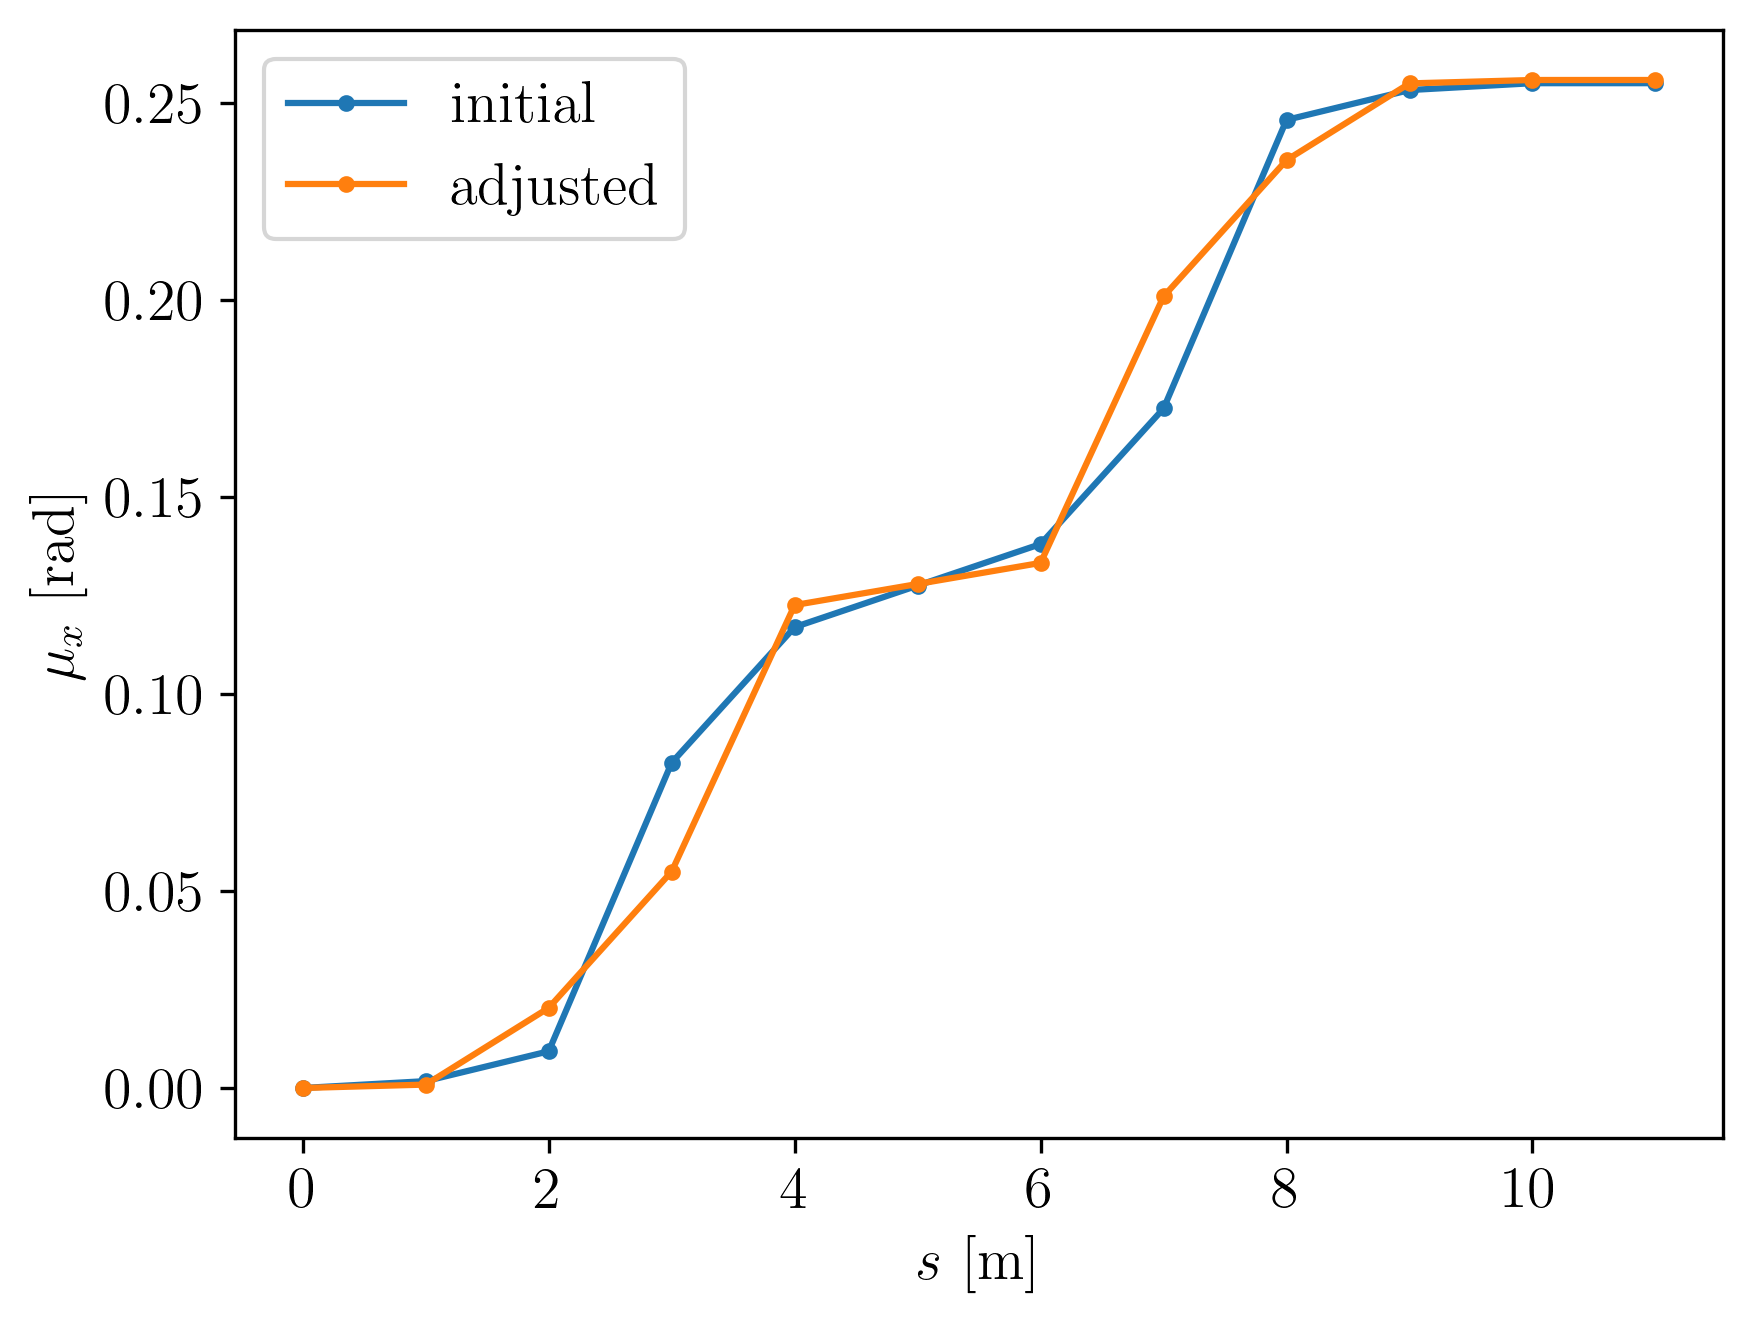

In [181]:
plt.plot(twiss_rhic.mux,'.-',label='initial')
plt.plot(twiss.mux,'.-',label='adjusted')
plt.xlabel('$s$ [m]')
plt.ylabel('$\mu_x$ [rad]')
plt.legend()
plt.show()

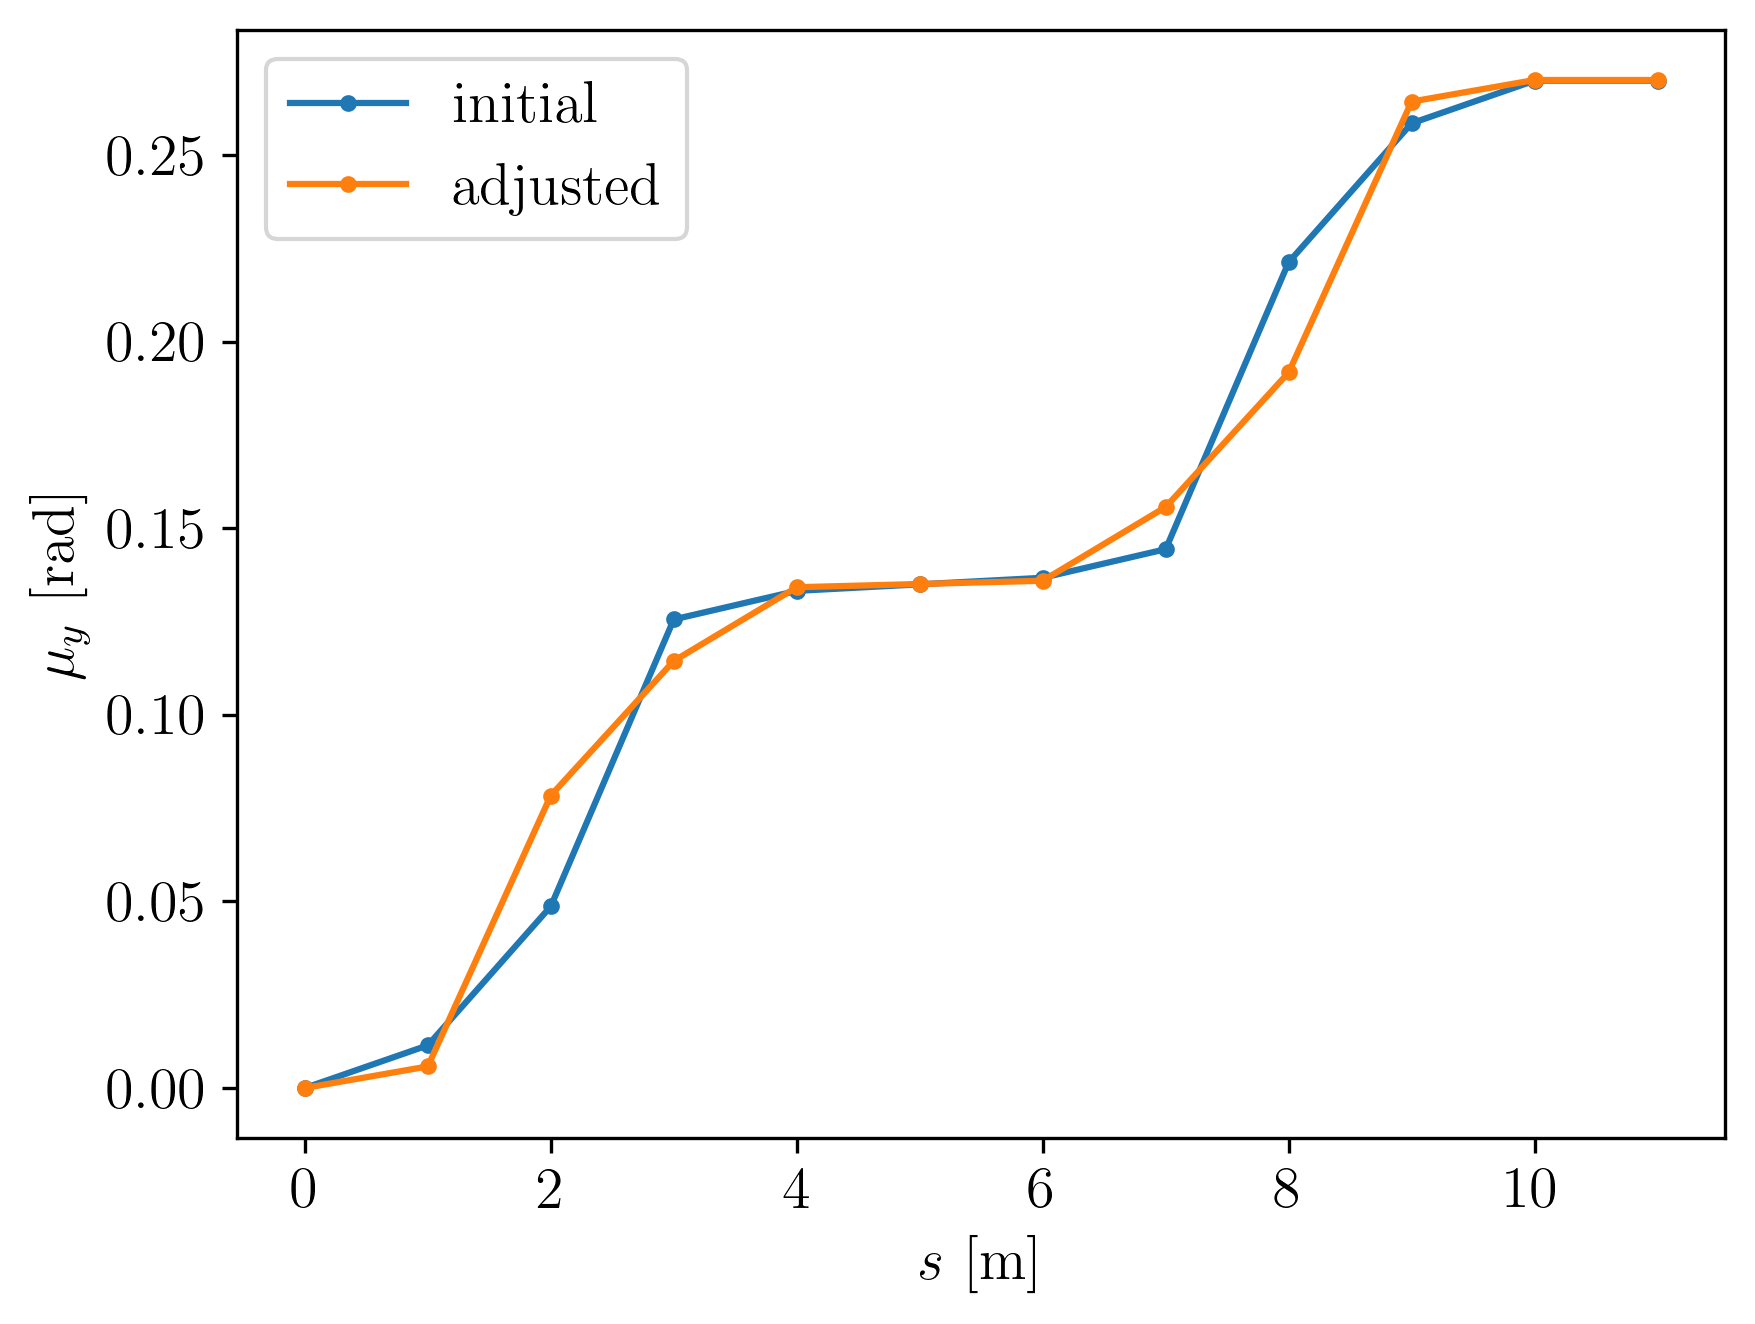

In [182]:
plt.plot(twiss_rhic.muy,'.-',label='initial')
plt.plot(twiss.muy,'.-',label='adjusted')
plt.xlabel('$s$ [m]')
plt.ylabel('$\mu_y$ [rad]')
plt.legend()
plt.show()

### Dispersion

In [183]:
L_vals = np.arange(0,7,0.5)
D_vals = []
for L in L_vals:
    madx = Madx(stdout=False)
    madx.input(f'''
    !==================================================
    ! RHIC FODO cell
    ! Authors: Todd Satogata, Steve Peggs 
    ! Last edited: February 28 2024
    !==================================================

    BEAM, particle = proton, energy = 275.0;
    ASSIGN, echo = madx.log;

    TITLE,'RHIC fodo cell';

    ! Geometry
    LQUAD = 1.11;                               ! Total quad length
    LDIP  = 9.45;                               ! Arc dipole length
    THETA = 0.038924;                           ! Arc dipole bend angle 

    ! Strengths
    KF =  0.09020;                              ! m^(-2)
    KD = -0.09320;                              ! m^(-2)

    ! Magnets
    QFH: QUADRUPOLE, L = 0.5*LQUAD, K1= KF/2.025;           ! HALF quads
    QDH: QUADRUPOLE, L = 0.5*LQUAD, K1= KD/2.025;
    DRI: DRIFT,      L = 2.116775*{L};
    DIPRHIC: SBEND,  L = LDIP, ANGLE = THETA;         ! Main arc dipole
    SLICE: SBEND,    L = 0.1*LDIP, ANGLE = 0.1*THETA; ! Slice of a dipole

    ! Beamlines
    fodo_rhic:   LINE=(QFH, DRI, DIPRHIC,  DRI, 2*QDH, DRI, DIPRHIC,  DRI, QFH);
    fodo_sliced: LINE=(QFH, DRI, 10*SLICE, DRI, 2*QDH, DRI, 10*SLICE, DRI, QFH);

    ! Define the columns & formats used in the *.twi output files
    SELECT, FLAG=TWISS, COLUMN = name,s,betx,bety,alfx,alfy,dx,mux,muy;
    SET, format="-22s", "11.6f";

    USE, SEQUENCE = fodo_rhic;
    MATCH, SEQUENCE = fodo_rhic;
    TWISS, SAVE, FILE = fodo_rhic.twi;
    PLOT, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

    USE, SEQUENCE = fodo_sliced;
    MATCH, SEQUENCE = fodo_sliced;
    TWISS, SAVE, FILE = fodo_sliced.twi;
    PLOT, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

    USE, SEQUENCE = fodo_rhic;
    MATCH, SEQUENCE = fodo_rhic;
    TWISS, SAVE, FILE = fodo_interpolate.twi;
    PLOT, interpolate, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

    stop;
    ''')
    twiss = madx.table.twiss
    D_vals.append(twiss.dx)

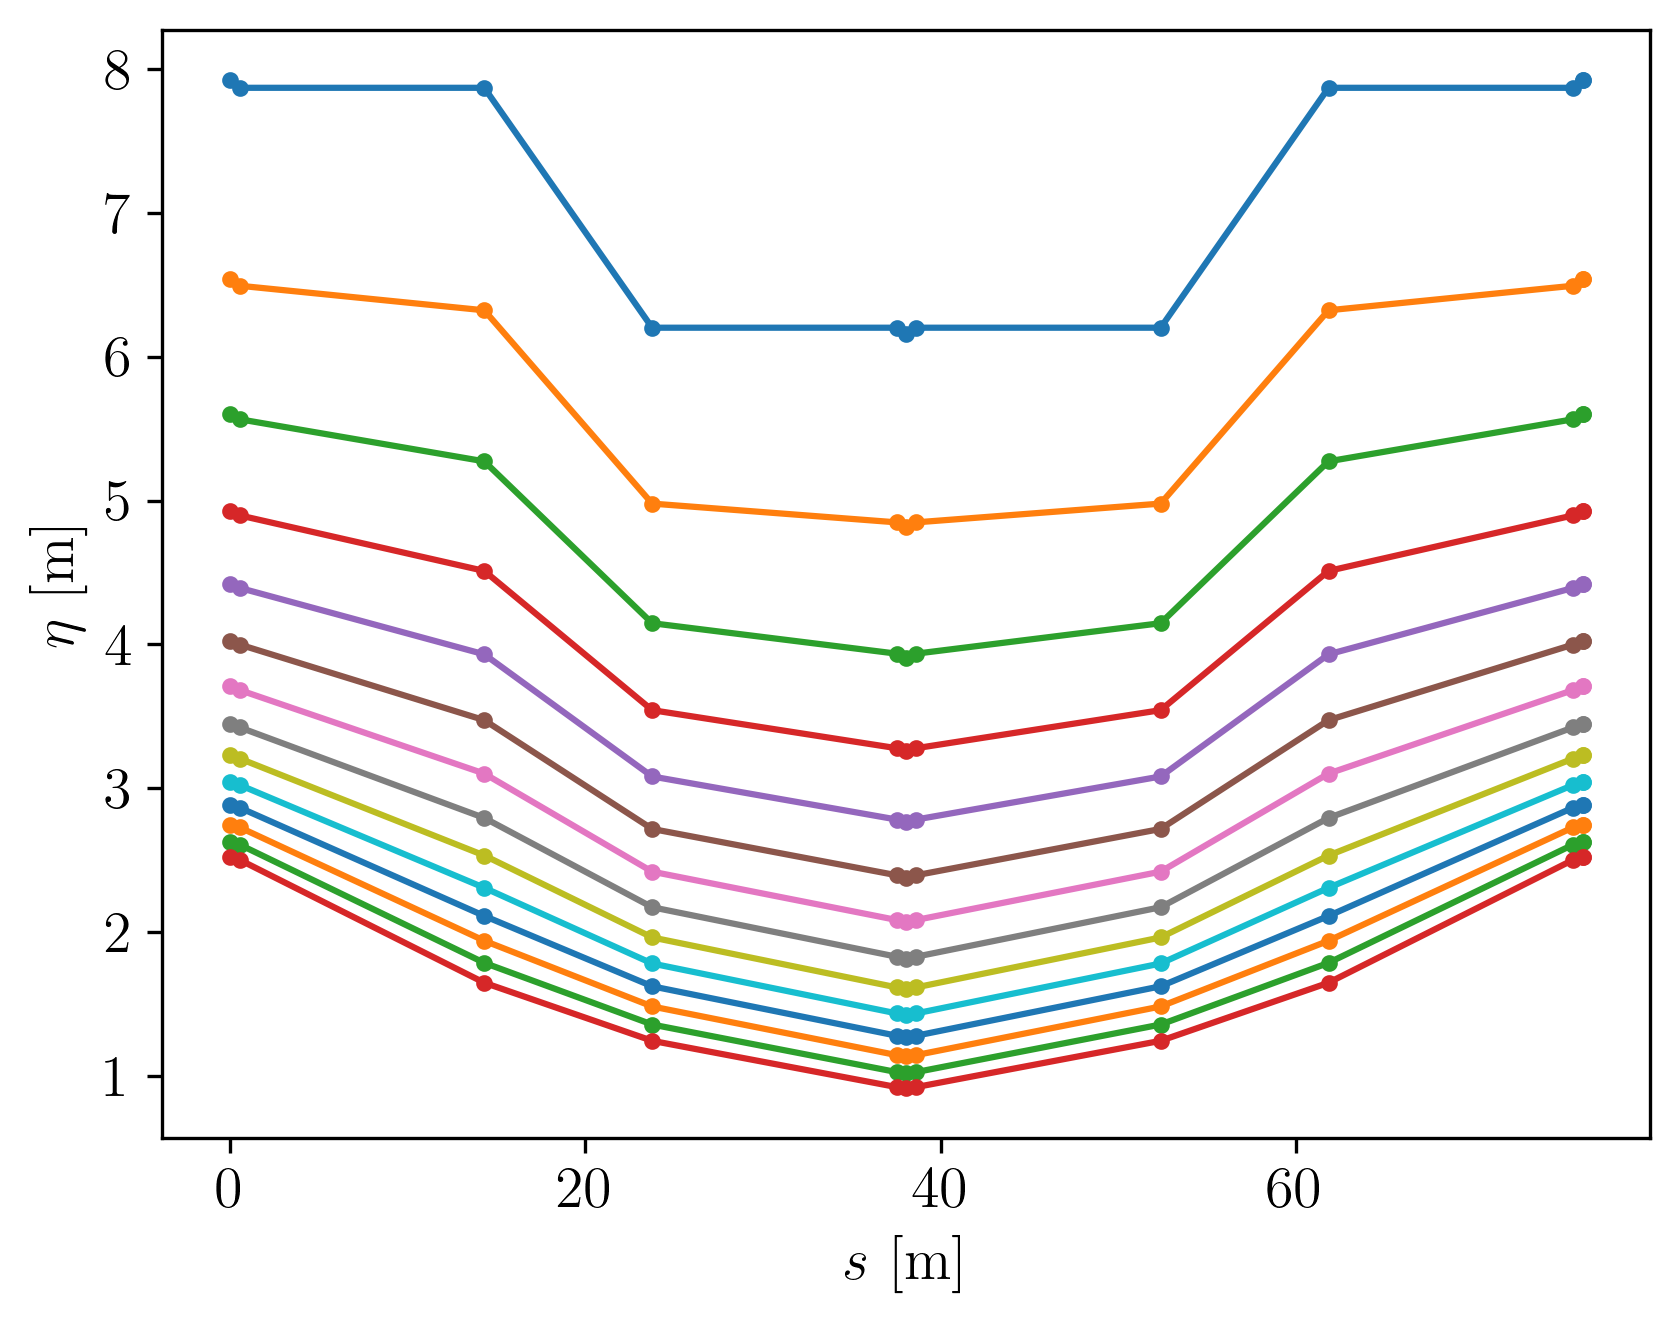

In [184]:
plt.figure()
for i in range(len(D_vals)):
    plt.plot(twiss.s,D_vals[i],'.-')
plt.xlabel('$s$ [m]')
plt.ylabel('$\eta$ [m]')
plt.show()

### Observations

- As the length of the drift region increases, the dispersion decreases.

In [185]:
############## say more words ##############

To study the dependence of $\eta_{max}/\eta_{min}$ on the phase advance, let us construct a loop to adjust the quadrupole strength, which affects $\Delta\phi$:

In [186]:
q_vals = np.arange(0.6,1.4,0.1)
dphi_vals = []
etarat_vals = []
for q in q_vals:
    madx = Madx(stdout=False)
    madx.input(f'''
    !==================================================
    ! RHIC FODO cell
    ! Authors: Todd Satogata, Steve Peggs 
    ! Last edited: February 28 2024
    !==================================================

    BEAM, particle = proton, energy = 275.0;
    ASSIGN, echo = madx.log;

    TITLE,'RHIC fodo cell';

    ! Geometry
    LQUAD = 1.11;                               ! Total quad length
    LDIP  = 9.45;                               ! Arc dipole length
    THETA = 0.038924;                           ! Arc dipole bend angle 

    ! Strengths
    KF =  0.09020;                              ! m^(-2)
    KD = -0.09320;                              ! m^(-2)

    ! Magnets
    QFH: QUADRUPOLE, L = 0.5*LQUAD, K1= KF*{q};           ! HALF quads
    QDH: QUADRUPOLE, L = 0.5*LQUAD, K1= KD*{q};
    DRI: DRIFT,      L = 2.116775;
    DIPRHIC: SBEND,  L = LDIP, ANGLE = THETA;         ! Main arc dipole
    SLICE: SBEND,    L = 0.1*LDIP, ANGLE = 0.1*THETA; ! Slice of a dipole

    ! Beamlines
    fodo_rhic:   LINE=(QFH, DRI, DIPRHIC,  DRI, 2*QDH, DRI, DIPRHIC,  DRI, QFH);
    fodo_sliced: LINE=(QFH, DRI, 10*SLICE, DRI, 2*QDH, DRI, 10*SLICE, DRI, QFH);

    ! Define the columns & formats used in the *.twi output files
    SELECT, FLAG=TWISS, COLUMN = name,s,betx,bety,alfx,alfy,dx,mux,muy;
    SET, format="-22s", "11.6f";

    USE, SEQUENCE = fodo_rhic;
    MATCH, SEQUENCE = fodo_rhic;
    TWISS, SAVE, FILE = fodo_rhic.twi;
    PLOT, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

    USE, SEQUENCE = fodo_sliced;
    MATCH, SEQUENCE = fodo_sliced;
    TWISS, SAVE, FILE = fodo_sliced.twi;
    PLOT, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

    USE, SEQUENCE = fodo_rhic;
    MATCH, SEQUENCE = fodo_rhic;
    TWISS, SAVE, FILE = fodo_interpolate.twi;
    PLOT, interpolate, HAXIS=S, VAXIS1 =BETX,BETY, VAXIS2=DX, VMIN=0,0, VMAX=60,2, colour=100, file = frhic;

    stop;
    ''')
    twiss = madx.table.twiss
    dphi_vals.append((np.max(twiss.mux)-np.min(twiss.mux)))
    etarat_vals.append(np.max(twiss.dx)/np.min(twiss.dx))

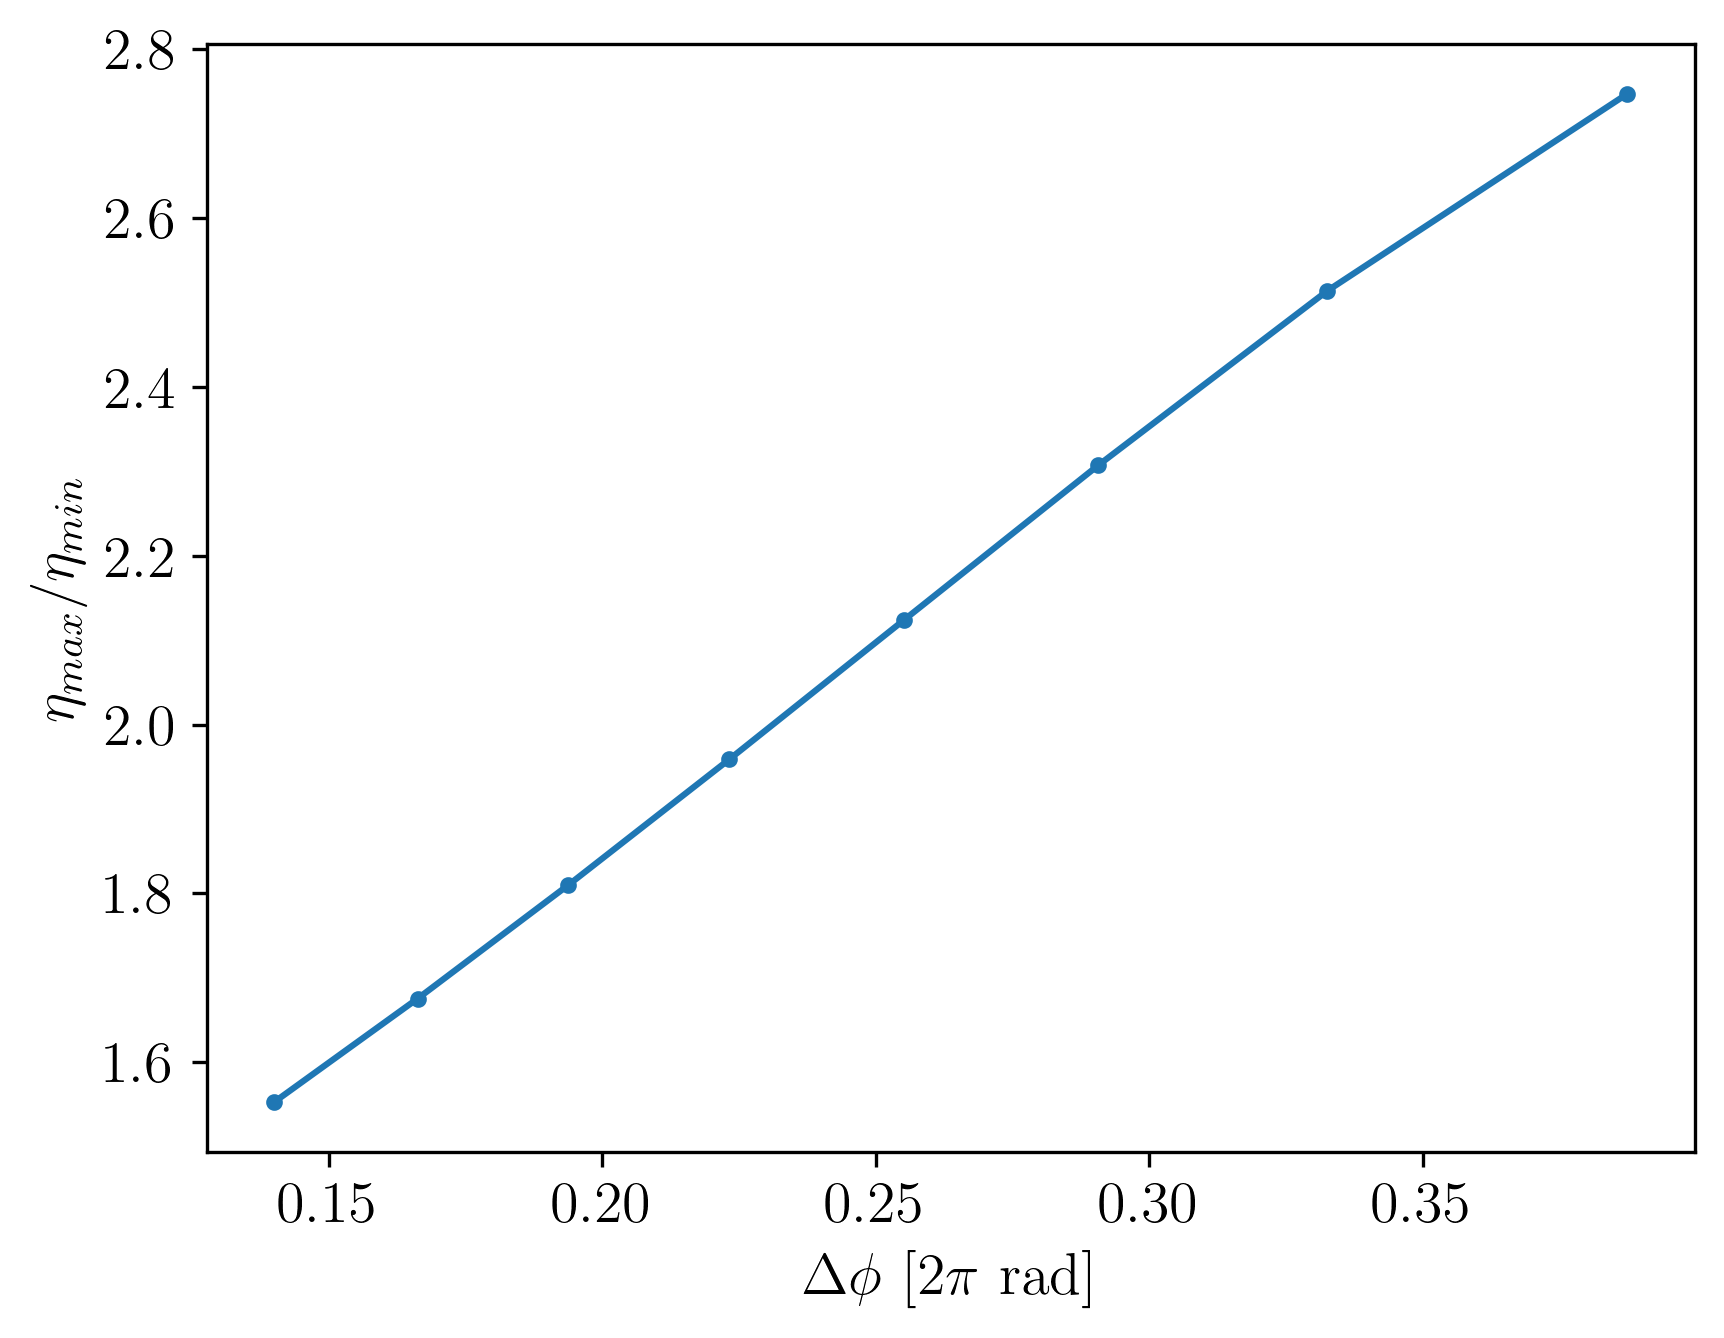

In [187]:
plt.plot(dphi_vals,etarat_vals,'.-')
plt.xlabel('$\Delta\phi$ [$2\pi$ rad]')
plt.ylabel('$\eta_{max}/\eta_{min}$')
plt.show()

### Observations

- The ratio of the maximum to minimum dispersion depends approximately linearly on the phase advance.

In [188]:
############## say more words ##############